## 03. Processed creation

In [69]:
import pandas as pd
import dtale

# Function to show df in D-Tale
def show_df_in_dtale(df):
    instance = dtale.show(df)
    instance.kill()
    d = dtale.show(df, enable_custom_filters=True)
    print(f"D-Tale running on: {d._main_url}")

In [79]:
#df_products = pd.read_excel("../data/Lecta/raw/LECTA - Aquiles_products.xlsx")
df = pd.read_csv("../data/Lecta/interim/lecta_interim.csv", sep=";")
df

,datetime,type,value
0,2023-12-12,40000892_1201,460.8
1,2023-12-13,40000892_1201,0.0
2,2023-12-14,40000892_1201,0.0
3,2023-12-15,40000892_1201,0.0
4,2023-12-16,40000892_1201,0.0
...,...,...,...
167672,2026-03-12,60011214_2204,0.0
167673,2026-03-13,60011214_2204,0.0
167674,2026-03-14,60011214_2204,0.0
167675,2026-03-15,60011214_2204,0.0


In [57]:
df.value_counts('type')

type
40002456_4201    2738
40002351_4201    2731
40002301_4201    2728
60001362_4201    2692
60001765_4201    2679
                 ... 
40002421_1203       1
40100384_4201       1
60001535_4201       1
60001755_1204       1
60001764_4201       1
Name: count, Length: 208, dtype: int64

In [80]:
def get_week_start(dates: pd.Series) -> pd.Series:
    """Convert dates to the Monday start date of their calendar week."""
    dates = pd.to_datetime(dates).dt.normalize()
    return dates - pd.to_timedelta(dates.dt.weekday, unit="D")
    
df["week"] = get_week_start(df["datetime"])

df

,datetime,type,value,week
0,2023-12-12,40000892_1201,460.8,2023-12-11
1,2023-12-13,40000892_1201,0.0,2023-12-11
2,2023-12-14,40000892_1201,0.0,2023-12-11
3,2023-12-15,40000892_1201,0.0,2023-12-11
4,2023-12-16,40000892_1201,0.0,2023-12-11
...,...,...,...,...
167672,2026-03-12,60011214_2204,0.0,2026-03-09
167673,2026-03-13,60011214_2204,0.0,2026-03-09
167674,2026-03-14,60011214_2204,0.0,2026-03-09
167675,2026-03-15,60011214_2204,0.0,2026-03-09


In [ ]:
df = (
        df
        .groupby(["type", "week"], as_index=False)["value"]
        .sum()
        .sort_values(["type", "week"])
        .reset_index(drop=True)
    )

df

,type,week,value
0,40000892_1201,2023-12-11,460.8
1,40000892_1201,2023-12-18,1382.4
2,40000892_1201,2023-12-25,1843.2
3,40000892_1201,2024-01-01,921.6
4,40000892_1201,2024-01-08,2764.8
...,...,...,...
24123,60011214_2204,2026-02-16,140.0
24124,60011214_2204,2026-02-23,0.0
24125,60011214_2204,2026-03-02,420.0
24126,60011214_2204,2026-03-09,0.0


In [82]:
# Remove last week per type
df = df[
    df["week"] != df.groupby("type")["week"].transform("max")
].reset_index(drop=True)

df

,type,week,value
0,40000892_1201,2023-12-11,460.8
1,40000892_1201,2023-12-18,1382.4
2,40000892_1201,2023-12-25,1843.2
3,40000892_1201,2024-01-01,921.6
4,40000892_1201,2024-01-08,2764.8
...,...,...,...
23915,60011214_2204,2026-02-09,140.0
23916,60011214_2204,2026-02-16,140.0
23917,60011214_2204,2026-02-23,0.0
23918,60011214_2204,2026-03-02,420.0


In [74]:
df.value_counts('type')

type
40002456_4201    391
40002351_4201    390
40002301_4201    389
60001362_4201    384
60001765_4201    383
                ... 
60001765_1203     10
40102278_3201      7
60001764_1201      7
40001697_1203      6
40000892_1204      4
Name: count, Length: 200, dtype: int64

In [83]:
# Consider min of 104 weeks
df = (
    df.sort_values(["type", "week"])
      .groupby("type")
      .head(-1)
      .reset_index(drop=True)
)

df

,type,week,value
0,40000892_1201,2023-12-11,460.8
1,40000892_1201,2023-12-18,1382.4
2,40000892_1201,2023-12-25,1843.2
3,40000892_1201,2024-01-01,921.6
4,40000892_1201,2024-01-08,2764.8
...,...,...,...
23715,60011214_2204,2026-02-02,140.0
23716,60011214_2204,2026-02-09,140.0
23717,60011214_2204,2026-02-16,140.0
23718,60011214_2204,2026-02-23,0.0


In [ ]:
show_df_in_dtale(df)

2026-05-29 19:26:56,873 - INFO     - Executing shutdown...
2026-05-29 19:26:56,874 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer
2026-05-29 19:26:58,147 - WARNING  - Custom filtering enabled. Custom filters are vulnerable to code injection attacks, please only use in trusted environments.


D-Tale running on: http://PC-104:40000/dtale/main/1


In [84]:
import matplotlib.pyplot as plt


def plot_issue_quantity_line(df, type):

    filtered_transactions = df.loc[
        df['type'] == type,
        ['week', 'value'],
    ].copy()

    if filtered_transactions.empty:
        raise ValueError(f"No data found for product_warehouse='{type}'")


    figure_width = max(12, len(filtered_transactions) * 0.15)
    fig, ax = plt.subplots(figsize=(figure_width, 6))
    ax.plot(
        filtered_transactions['week'],
        filtered_transactions['value'],
        marker='o',
        linewidth=2,
        markersize=4,
    )
    ax.set_title(f'Issue Quantity - {type}')
    ax.set_xlabel('week')
    ax.set_ylabel('value')
    ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()

In [87]:
df.to_csv("../data/Lecta/processed/lecta_processed.csv", sep=";", index=False)

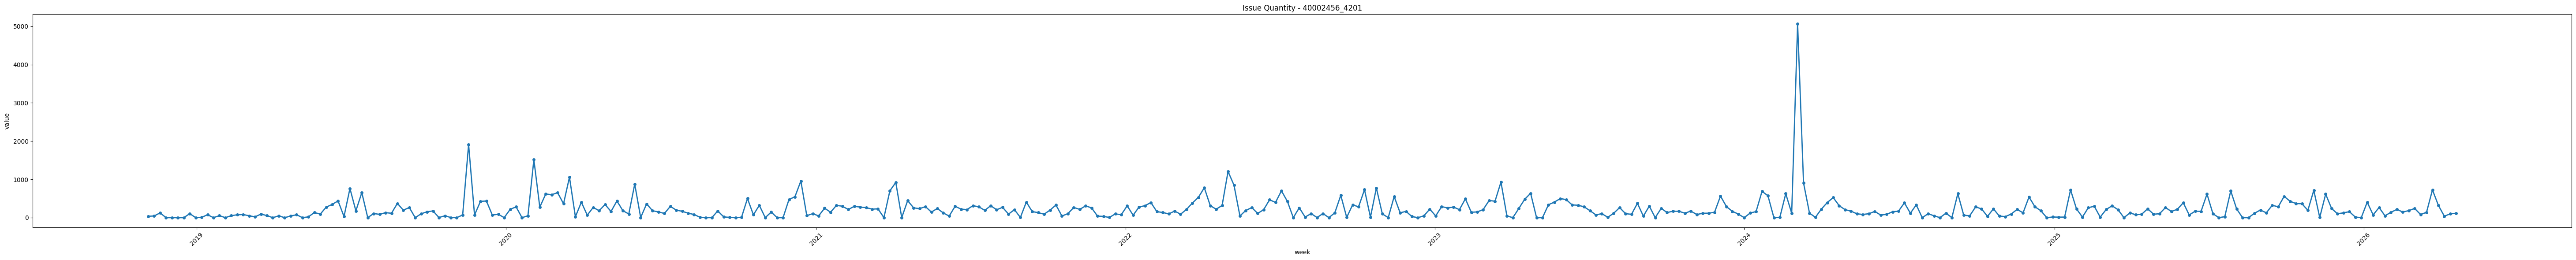

In [66]:
plot_issue_quantity_line(df, type='40002456_4201')

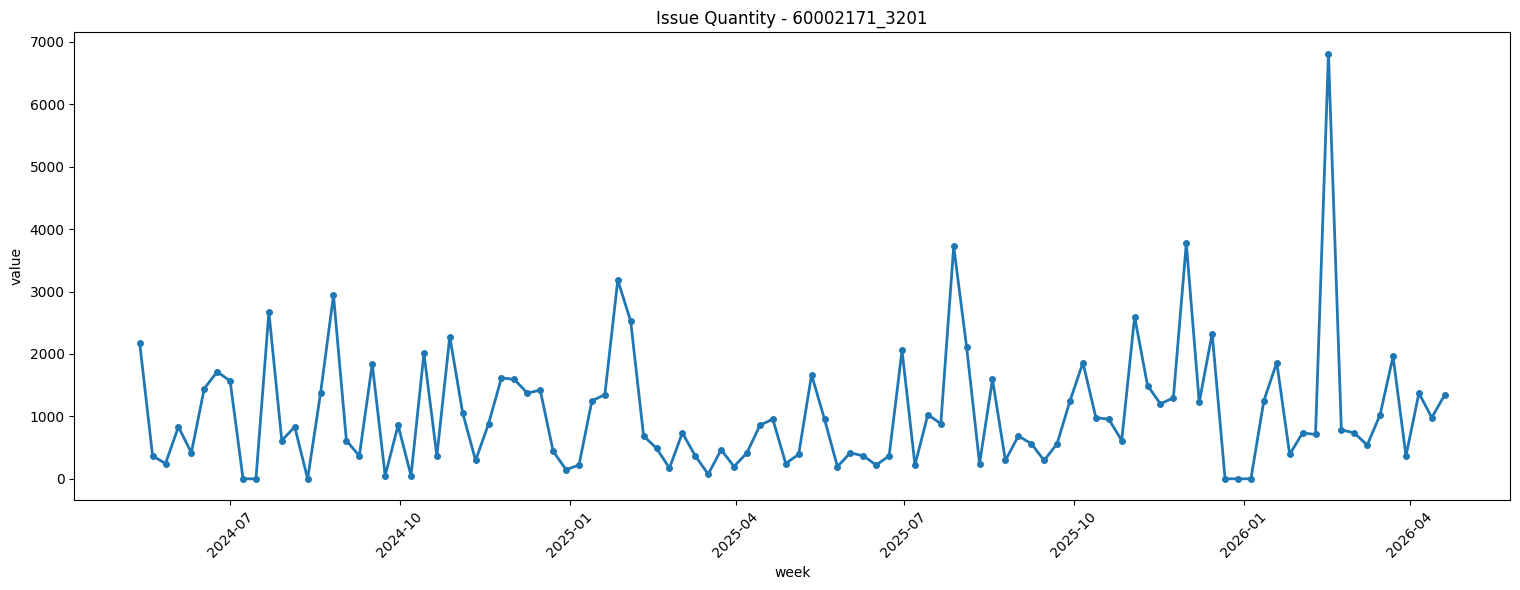

In [67]:
plot_issue_quantity_line(df, type='60002171_3201')

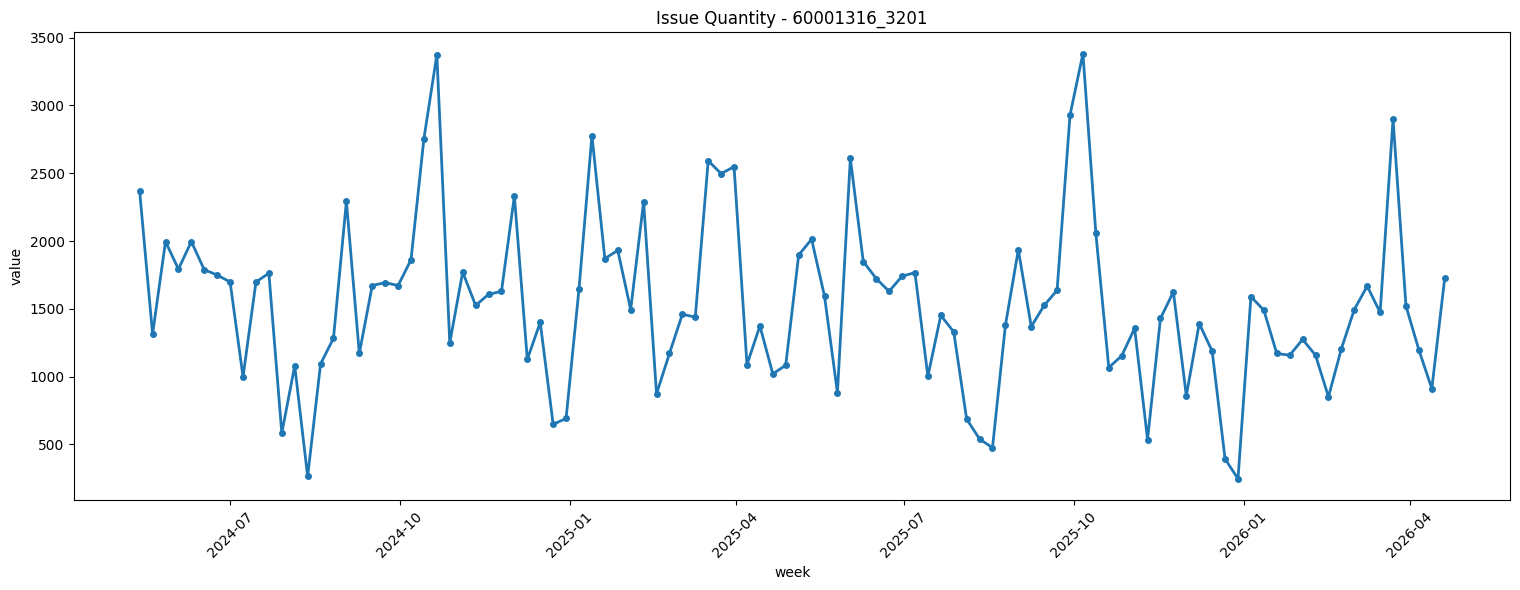

In [68]:
plot_issue_quantity_line(df, type='60001316_3201')